# Use of Songs Added in the 1991 Edition

This notebook explores how songs newly added to the 1991 Denson edition were used over time, including overall yearly contours, song-by-song trajectories, and regional differences.

Metric notes:

- A **lesson** is counted as one distinct `(minutes_id, lesson_id, song_id)`, so two people jointly leading the same song in the same lesson do not double count the song.
- A **singing record/day** is counted as one `minutes` row. Some rows cover multi-day conventions, so treat this as a practical database unit rather than a perfect day-level measure.
- `minutes.Year` is the minute-book year, not always the singing year. The notebook derives `singing_year` from `DateOrdinal` when available and otherwise parses `minutes.Date`.

In [1]:
from pathlib import Path
import datetime as dt
import itertools
import re
import sqlite3

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import seaborn as sns
sns.set_theme(style="whitegrid")

DB_PATH = Path("minutes_pre95.db")
NEW_SONGS_PATH = Path("1991newsongs.txt")

assert DB_PATH.exists(), f"Missing database: {DB_PATH}"
assert NEW_SONGS_PATH.exists(), f"Missing new-song list: {NEW_SONGS_PATH}"

## Load Song And Minutes Data

In [2]:
def read_1991_new_songs(path: Path) -> pd.DataFrame:
    rows = []
    for line in path.read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        page, title = line.split(" ", 1)
        rows.append({"page_num": page, "listed_title": title})
    return pd.DataFrame(rows)

conn = sqlite3.connect(DB_PATH)

new_song_pages = read_1991_new_songs(NEW_SONGS_PATH)

songs_1991 = pd.read_sql_query(
    """
    SELECT bsj.page_num, bsj.song_id, songs.title
    FROM book_song_joins bsj
    JOIN books ON books.id = bsj.book_id
    JOIN songs ON songs.id = bsj.song_id
    WHERE books.year = 1991
    """,
    conn,
)

new_songs = new_song_pages.merge(songs_1991, on="page_num", how="left")
missing = new_songs[new_songs.song_id.isna()]
assert missing.empty, missing
new_songs["song_id"] = new_songs["song_id"].astype(int)
new_song_ids = set(new_songs.song_id)

minutes = pd.read_sql_query(
    """
    SELECT id AS minutes_id, Name, Location, Date, Year AS book_year,
           DateOrdinal, DensonYear, IsDenson, IsVirtual
    FROM minutes
    WHERE IsDenson = 1 AND COALESCE(IsVirtual, 0) = 0
    """,
    conn,
)

lessons = pd.read_sql_query(
    """
    SELECT DISTINCT minutes_id, lesson_id, song_id
    FROM song_leader_joins
    WHERE minutes_id IS NOT NULL AND lesson_id IS NOT NULL AND song_id IS NOT NULL
    """,
    conn,
)

leaders_by_minutes = pd.read_sql_query(
    """
    SELECT DISTINCT minutes_id, leader_id
    FROM song_leader_joins
    WHERE minutes_id IS NOT NULL AND leader_id IS NOT NULL
    """,
    conn,
)

location_rows = pd.read_sql_query(
    """
    SELECT mlj.minutes_id,
           GROUP_CONCAT(DISTINCT locations.state_province) AS state_province,
           GROUP_CONCAT(DISTINCT locations.country) AS country
    FROM minutes_location_joins mlj
    JOIN locations ON locations.id = mlj.location_id
    GROUP BY mlj.minutes_id
    """,
    conn,
)

conn.close()

new_songs.head(), minutes.shape, lessons.shape

(  page_num listed_title  song_id       title
 0      34b   St. Thomas       17  St. Thomas
 1      50b     Humility       45    Humility
 2      50t    Mortality       43   Mortality
 3       66       Jordan       67      Jordan
 4      77b     Holcombe       86    Holcombe,
 (6802, 9),
 (549742, 3))

## Derive Singing Year


In [3]:
MONTHS = "January February March April May June July August September October November December".split()
DATE_RE = re.compile(r"(" + "|".join(MONTHS) + r")\s+(\d{1,2}).*?(\d{4})", re.I)
MONTH_RE = re.compile(r"(" + "|".join(MONTHS) + r")", re.I)
CURRENT_YEAR = dt.date.today().year


def plausible_singing_year(year, book_year=None):
    if pd.isna(year):
        return False
    year = int(year)
    if year < 1980 or year > CURRENT_YEAR + 1:
        return False
    if pd.notna(book_year) and abs(year - int(book_year)) > 1:
        return False
    return True


def fallback_year_from_book(row):
    if pd.isna(row.book_year):
        return np.nan
    book_year = int(row.book_year)
    month_match = MONTH_RE.search(str(row.Date))
    if month_match and month_match.group(1).lower() == "december":
        return book_year - 1
    return book_year


def singing_year_from_row(row) -> float:
    ordinal_year = np.nan
    if pd.notna(row.DateOrdinal):
        try:
            ordinal_year = dt.date.fromordinal(int(row.DateOrdinal)).year
        except ValueError:
            ordinal_year = np.nan
    if plausible_singing_year(ordinal_year, row.book_year):
        return int(ordinal_year)

    match = DATE_RE.search(str(row.Date))
    text_year = int(match.group(3)) if match else np.nan
    if plausible_singing_year(text_year, row.book_year):
        return int(text_year)

    return fallback_year_from_book(row)

STATE_ALIASES = {
    "alabama": "AL", "al": "AL", "georgia": "GA", "ga": "GA",
    "mississippi": "MS", "ms": "MS", "tennessee": "TN", "tn": "TN",
    "florida": "FL", "fl": "FL", "texas": "TX", "tx": "TX",
    "louisiana": "LA", "la": "LA", "arkansas": "AR", "ar": "AR",
    "north carolina": "NC", "nc": "NC", "south carolina": "SC", "sc": "SC",
    "virginia": "VA", "va": "VA", "west virginia": "WV", "wv": "WV",
    "kentucky": "KY", "ky": "KY", "illinois": "IL", "il": "IL",
    "indiana": "IN", "in": "IN", "ohio": "OH", "oh": "OH",
    "michigan": "MI", "mi": "MI", "wisconsin": "WI", "wi": "WI",
    "minnesota": "MN", "mn": "MN", "missouri": "MO", "mo": "MO",
    "iowa": "IA", "ia": "IA", "kansas": "KS", "ks": "KS",
    "california": "CA", "ca": "CA", "oregon": "OR", "or": "OR",
    "washington": "WA", "wa": "WA", "colorado": "CO", "co": "CO",
    "new mexico": "NM", "nm": "NM", "arizona": "AZ", "az": "AZ",
    "new york": "NY", "ny": "NY", "massachusetts": "MA", "ma": "MA",
    "connecticut": "CT", "ct": "CT", "vermont": "VT", "vt": "VT",
    "maine": "ME", "me": "ME", "pennsylvania": "PA", "pa": "PA",
    "maryland": "MD", "md": "MD", "oregon": "OR", "ireland": "IE",
    "united kingdom": "UK", "england": "UK", "ontario": "ON", "canada": "CA-Canada",
}

def normalize_state(value):
    if pd.isna(value) or not str(value).strip():
        return None
    first = str(value).split(",")[0].strip()
    key = first.lower().replace(".", "")
    return STATE_ALIASES.get(key, first.upper() if len(first) == 2 else first)

def infer_state_from_text(*parts):
    text = " ".join(str(p) for p in parts if pd.notna(p)).lower().replace(".", " ")
    # Prefer long names before abbreviations so "Georgia" beats a stray "GA"-like token.
    for key in sorted(STATE_ALIASES, key=len, reverse=True):
        if re.search(r"\b" + re.escape(key) + r"\b", text):
            return STATE_ALIASES[key]
    return None

minutes = minutes.merge(location_rows, on="minutes_id", how="left")
minutes["singing_year"] = minutes.apply(singing_year_from_row, axis=1)
minutes["state"] = minutes["state_province"].map(normalize_state)
missing_state = minutes["state"].isna()
minutes.loc[missing_state, "state"] = minutes.loc[missing_state].apply(
    lambda row: infer_state_from_text(row.Location, row.Name), axis=1
)

year_audit = minutes.loc[
    (minutes.singing_year < 1980) |
    (minutes.singing_year > CURRENT_YEAR + 1) |
    (minutes.book_year.notna() & ((minutes.singing_year - minutes.book_year).abs() > 1)),
    ["minutes_id", "Name", "Date", "book_year", "DateOrdinal", "singing_year"],
]
assert year_audit.empty, year_audit

minutes[["minutes_id", "Name", "Date", "book_year", "singing_year", "state"]].head(10)

,minutes_id,Name,Date,book_year,singing_year,state
0,1,Liberty Church,"December 4, 1994",1995,1994,AL
1,2,Concord Primitive Baptist Church,"December 11, 1994",1995,1994,AL
2,3,Little Branch Primitive Baptist Church,"December 15, 1994",1995,1994,AL
3,4,Dutch Treat Singing,"January 1, 1995",1995,1995,AL
4,5,Original Dutch Singing,"January 1, 1995",1995,1995,GA
5,6,Friends Meetinghouse,"January 2, 1995",1995,1995,OH
6,8,Lillian Calvert and Irene Woodley Memorial,"January 7, 1995",1995,1995,AL
7,9,Jack and Henry Kerr Memorial,"January 8, 1995",1995,1995,AL
8,10,Anniversary Singing,"January 8, 1995",1995,1995,IL
9,11,All-California Sacred Harp Singing Convention,"January 15, 1995",1995,1995,CA


## Overall Yearly Use Of 1991 New Songs

In [4]:
lesson_facts = lessons.merge(
    minutes[["minutes_id", "singing_year"]],
    on="minutes_id",
    how="inner",
)
lesson_facts = lesson_facts.dropna(subset=["singing_year"])
lesson_facts["singing_year"] = lesson_facts["singing_year"].astype(int)
lesson_facts["is_1991_new"] = lesson_facts.song_id.isin(new_song_ids)

year_total = lesson_facts.groupby("singing_year").agg(
    total_lessons=("song_id", "size"),
    singing_records=("minutes_id", "nunique"),
)
year_new = lesson_facts[lesson_facts.is_1991_new].groupby("singing_year").agg(
    new_song_lessons=("song_id", "size"),
    records_with_new_song=("minutes_id", "nunique"),
)

yearly = year_total.join(year_new, how="left").fillna(0)
yearly["share_of_lessons"] = yearly.new_song_lessons / yearly.total_lessons
yearly["share_of_records"] = yearly.records_with_new_song / yearly.singing_records
yearly = yearly.reset_index()
yearly.head()

,singing_year,total_lessons,singing_records,new_song_lessons,records_with_new_song,share_of_lessons,share_of_records
0,1991,954,9,46,7,0.048218,0.777778
1,1992,14040,156,1530,139,0.108974,0.891026
2,1993,14082,160,1406,148,0.099844,0.925000
3,1994,14382,163,1325,155,0.092129,0.950920
4,1995,13647,164,1277,159,0.093574,0.969512


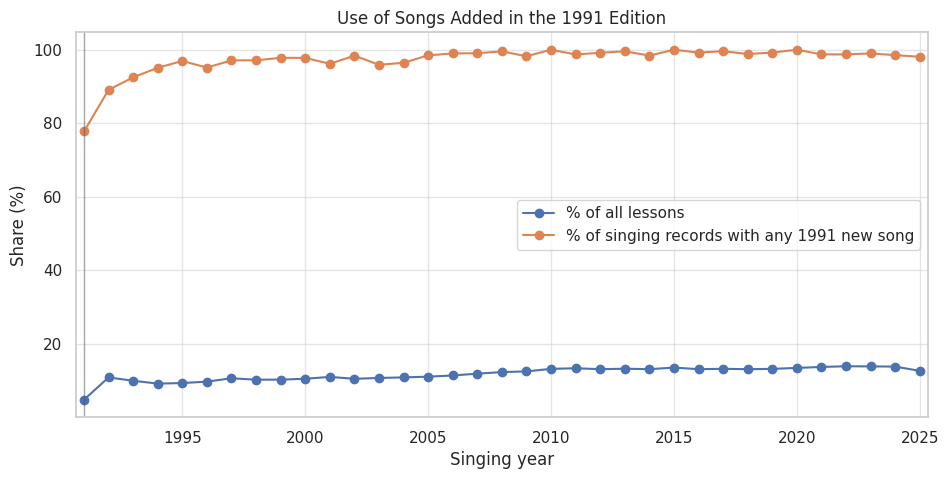

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(yearly.singing_year, yearly.share_of_lessons * 100, marker="o", label="% of all lessons")
ax.plot(yearly.singing_year, yearly.share_of_records * 100, marker="o", label="% of singing records with any 1991 new song")
ax.axvline(1991, color="0.3", lw=1, alpha=0.5)
ax.set_title("Use of Songs Added in the 1991 Edition")
ax.set_xlabel("Singing year")
ax.set_ylabel("Share (%)")
ax.legend()
ax.margins(x=0.01)
plt.show()

### Initial Burst vs Later Use

This bins the contour into eras. Change the year ranges if another periodization makes more sense.

In [6]:
bins = [1990, 1994, 1999, 2009, 2019, 2100]
labels = ["1991-1994", "1995-1999", "2000-2009", "2010-2019", "2020+"]
lesson_facts["era"] = pd.cut(lesson_facts.singing_year, bins=bins, labels=labels)
era_summary = lesson_facts.groupby("era", observed=True).agg(
    total_lessons=("song_id", "size"),
    new_song_lessons=("is_1991_new", "sum"),
    singing_records=("minutes_id", "nunique"),
)
era_days = lesson_facts[lesson_facts.is_1991_new].groupby("era", observed=True).minutes_id.nunique()
era_summary["records_with_new_song"] = era_days
era_summary = era_summary.fillna(0)
era_summary["share_of_lessons"] = era_summary.new_song_lessons / era_summary.total_lessons
era_summary["share_of_records"] = era_summary.records_with_new_song / era_summary.singing_records
era_summary

,total_lessons,new_song_lessons,singing_records,records_with_new_song,share_of_lessons,share_of_records
era,,,,,,
1991-1994,43458,4307,488,449,0.099107,0.920082
1995-1999,71361,7192,858,831,0.100783,0.968531
2000-2009,167439,18999,2005,1964,0.113468,0.979551
2010-2019,201693,26708,2477,2459,0.132419,0.992733
2020+,65791,8907,924,912,0.135383,0.987013


## Song-By-Song Trajectories

In [7]:
song_year_counts = lesson_facts[lesson_facts.song_id.isin(new_song_ids)].groupby(["song_id", "singing_year"]).agg(
    lessons=("song_id", "size"),
    singing_records=("minutes_id", "nunique"),
).reset_index()
song_year_counts = song_year_counts.merge(year_total.reset_index(), on="singing_year", how="left")
song_year_counts = song_year_counts.merge(new_songs[["song_id", "page_num", "title"]], on="song_id", how="left")
song_year_counts["share_of_all_lessons"] = song_year_counts.lessons / song_year_counts.total_lessons
song_year_counts["share_of_records"] = song_year_counts.singing_records_x / song_year_counts.singing_records_y
song_year_counts = song_year_counts.rename(columns={"singing_records_x": "song_records", "singing_records_y": "all_records"})

top_new_songs = (song_year_counts.groupby(["song_id", "page_num", "title"]).lessons.sum()
                 .sort_values(ascending=False).head(40).reset_index())
top_new_songs

,song_id,page_num,title,lessons
0,549,475,A Thankful Heart,3723
1,214,178,Africa,3503
2,591,503,Lloyd,3319
3,17,34b,St. Thomas,2998
4,197,163b,China,2260
5,387,344,Rainbow,2256
6,264,225t,Reynolds,2218
7,546,472,Akin,2187
8,67,66,Jordan,2079
9,102,86,Poland,1959


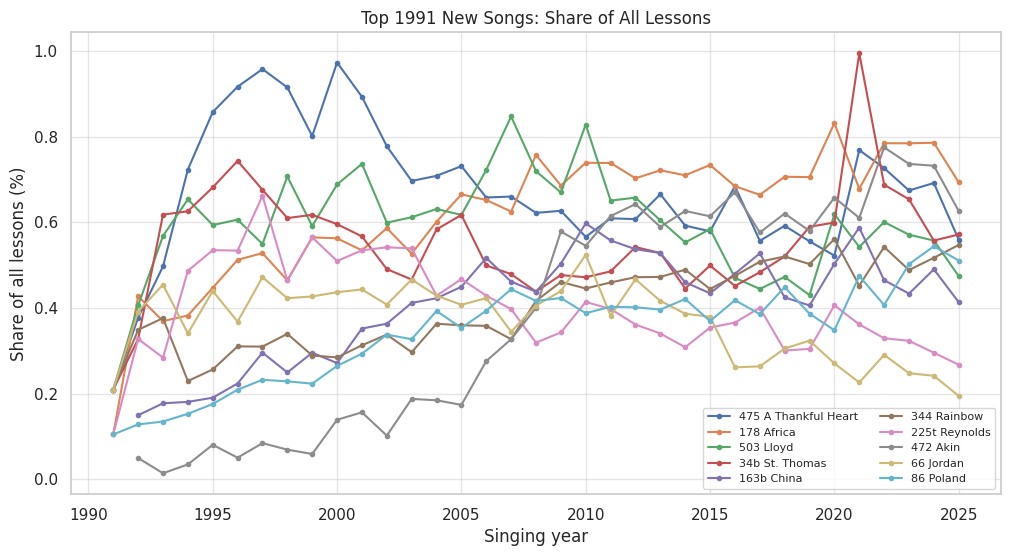

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
for _, song in top_new_songs.head(10).iterrows():
    group = song_year_counts[song_year_counts.song_id == song.song_id]
    label = f"{song.page_num} {song.title}"
    ax.plot(group.singing_year, group.share_of_all_lessons * 100, marker="o", ms=3, label=label)
ax.set_title("Top 1991 New Songs: Share of All Lessons")
ax.set_xlabel("Singing year")
ax.set_ylabel("Share of all lessons (%)")
ax.legend(fontsize=8, ncol=2)
plt.show()

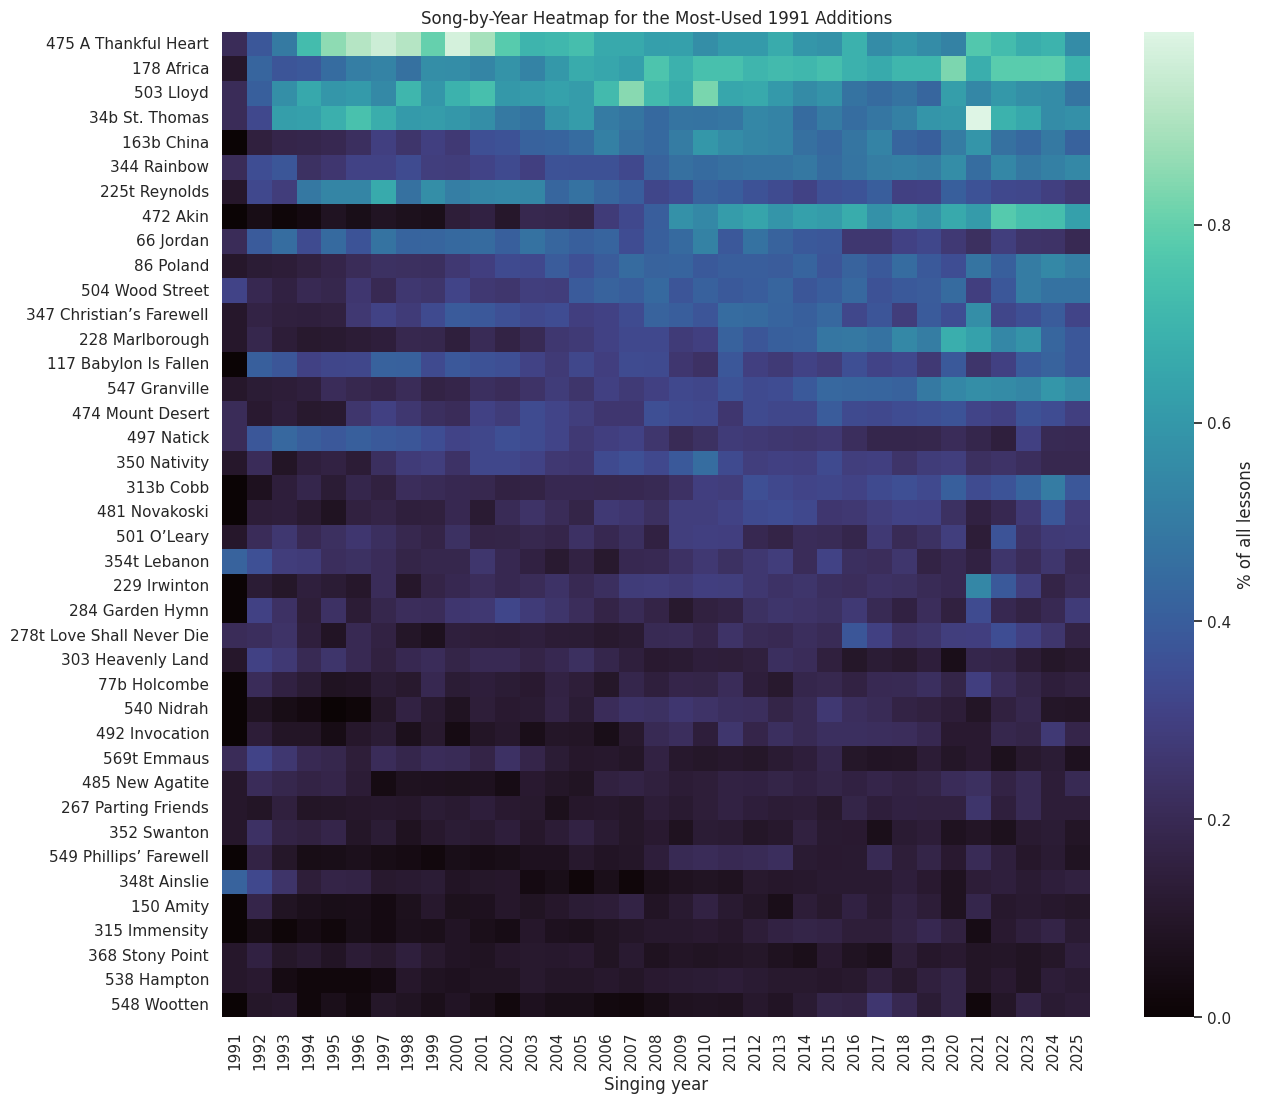

In [9]:
heat = song_year_counts.merge(top_new_songs.head(40)[["song_id"]], on="song_id")
heat["song_label"] = heat.page_num + " " + heat.title
pivot = heat.pivot_table(index="song_label", columns="singing_year", values="share_of_all_lessons", fill_value=0)
pivot = pivot.loc[heat.groupby("song_label").lessons.sum().sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, max(6, len(pivot) * 0.32)))
if sns:
    sns.heatmap(pivot * 100, cmap="mako", ax=ax, cbar_kws={"label": "% of all lessons"})
else:
    im = ax.imshow(pivot * 100, aspect="auto")
    ax.set_yticks(range(len(pivot.index)), pivot.index)
    ax.set_xticks(range(len(pivot.columns)), pivot.columns, rotation=90)
    fig.colorbar(im, ax=ax, label="% of all lessons")
ax.set_title("Song-by-Year Heatmap for the Most-Used 1991 Additions")
ax.set_xlabel("Singing year")
ax.set_ylabel("")
plt.show()

## Did Some Songs Start Fast While Others Rose Later?

In [10]:
def era_total_for_song(start, end):
    mask = song_year_counts.singing_year.between(start, end)
    return song_year_counts[mask].groupby("song_id").lessons.sum()

early = era_total_for_song(1991, 1999)
middle = era_total_for_song(2000, 2010)
late = era_total_for_song(2011, int(lesson_facts.singing_year.max()))

rise = new_songs[["song_id", "page_num", "title"]].copy()
rise["early_lessons"] = rise.song_id.map(early).fillna(0).astype(int)
rise["middle_lessons"] = rise.song_id.map(middle).fillna(0).astype(int)
rise["late_lessons"] = rise.song_id.map(late).fillna(0).astype(int)
rise["late_minus_early"] = rise.late_lessons - rise.early_lessons
rise["early_share_of_song"] = rise.early_lessons / rise[["early_lessons", "middle_lessons", "late_lessons"]].sum(axis=1).replace(0, np.nan)
rise.sort_values("early_lessons", ascending=False).head(12)

,song_id,page_num,title,early_lessons,middle_lessons,late_lessons,late_minus_early,early_share_of_song
40,549,475,A Thankful Heart,863,1327,1533,670,0.231802
0,17,34b,St. Thomas,699,959,1340,641,0.233155
48,591,503,Lloyd,668,1305,1346,678,0.201265
10,264,225t,Reynolds,551,826,841,290,0.248422
9,214,178,Africa,528,1185,1790,1262,0.150728
3,67,66,Jordan,474,803,802,328,0.227994
46,581,497,Natick,444,537,564,120,0.287379
6,139,117,Babylon Is Fallen,412,583,812,400,0.228002
22,387,344,Rainbow,352,679,1225,873,0.156028
29,400,354t,Lebanon,279,353,580,301,0.230198


In [11]:
rise.sort_values("late_minus_early", ascending=False).head(12)

,song_id,page_num,title,early_lessons,middle_lessons,late_lessons,late_minus_early,early_share_of_song
38,546,472,Akin,63,541,1583,1520,0.028807
9,214,178,Africa,528,1185,1790,1262,0.150728
11,267,228,Marlborough,171,480,1164,993,0.094215
8,197,163b,China,252,822,1186,934,0.111504
54,641,547,Granville,194,499,1104,910,0.107958
22,387,344,Rainbow,352,679,1225,873,0.156028
5,102,86,Poland,213,690,1056,843,0.108729
49,592,504,Wood Street,245,658,1018,773,0.127538
23,391,347,Christian’s Farewell,259,669,951,692,0.137839
20,351,313b,Cobb,182,376,868,686,0.127630


## Things To Try Next

- Compare 1991 additions against a matched set of older songs with similar baseline popularity.
- Audit the pre-1995 OCR rows with large numbers of skipped song IDs, since Cooper-book and OCR artifacts can affect early-year estimates.
- Add regional analysis back later once the place/region definitions feel solid.
